# MACC readout modes and detector settings

The Lazuli near-infrared detector (an H4RG, from the HxRG family) is read out
*up-the-ramp* using the **MACC** (multi-accumulate) scheme: while charges accumulate, the
detector is read non-destructively many times, and the signal is measured from the slope of
the ramp. Understanding how the MACC parameters affect the noise is key to optimising your
observations.

This notebook explains:
- what the MACC parameters `(ngroups, nframes_per_group, ndrops)` mean;
- how they set the exposure time;
- how changing the readout mode shifts the balance between readout noise and photon noise;
- how to choose a mode for a given science case.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import slicersim

***
## 1. What is a MACC readout?

In a MACC readout, each *ramp* consists of:
- **ngroups**: the number of groups in the ramp;
- **nframes_per_group**: the number of frames averaged within each group (reduces the readout noise);
- **ndrops**: the number of frames dropped (read but not stored) between groups.

The duration of a ramp is set by the detector frame time and these three numbers.
Several ramps (`nramps`) can be taken to increase the total time on source.

```
nmd = (ngroups, nframes_per_group, ndrops)
```

Let us start with a reference supernova and inspect its default configuration.

In [2]:
# Reference SN Ia at z=1.0
snia = slicersim.LazuliSupernova(redshift=1.0)

# Default readout config
cfg = snia.get_readout_config()
print("Default readout config:")
print(cfg)

Default readout config:
{'nmd': [16, 8, 0], 'nramps': 1}


In [3]:
print(f"Default exposure time: {snia.get_exposure_time():.1f} s")

Default exposure time: 362.2 s


***
## 2. Changing the readout mode

`change_detector(nmd, nramps)` lets you set any MACC configuration.
The exposure time is set by the detector frame time, `nmd` and `nramps`.

In [4]:
# Short ramp: few groups, few frames
snia.change_detector(nmd=(10, 4, 0), nramps=1)
print(f"Short ramp  (10, 4, 0) x1 ramp:  {snia.get_exposure_time():.1f} s")

# Medium ramp
snia.change_detector(nmd=(40, 8, 0), nramps=1)
print(f"Medium ramp (40, 8, 0) x1 ramp:  {snia.get_exposure_time():.1f} s")

# Long ramp
snia.change_detector(nmd=(64, 8, 0), nramps=1)
print(f"Long ramp   (64, 8, 0) x1 ramp:  {snia.get_exposure_time():.1f} s")

# Long ramp x2
snia.change_detector(nmd=(64, 8, 0), nramps=2)
print(f"Long ramp   (64, 8, 0) x2 ramps: {snia.get_exposure_time():.1f} s")

Short ramp  (10, 4, 0) x1 ramp:  113.2 s
Medium ramp (40, 8, 0) x1 ramp:  905.6 s
Long ramp   (64, 8, 0) x1 ramp:  1449.0 s
Long ramp   (64, 8, 0) x2 ramps: 2897.9 s


***
## 3. Readout noise vs. photon noise

Fitting the slope of the ramp over many reads reduces the *effective* readout noise (RON)
compared to a single read. Longer ramps → lower effective RON relative to the collected
signal → photon noise becomes relatively more important.

Let us compare three readout modes and look at the variance budget.

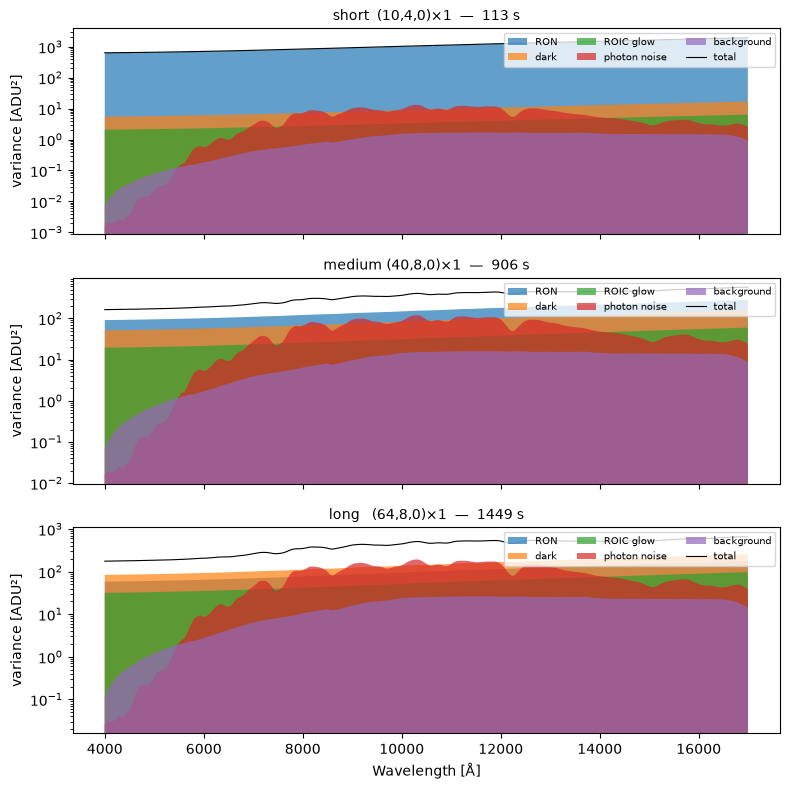

In [5]:
modes = {
    "short  (10,4,0)×1": (10, 4, 0, 1),
    "medium (40,8,0)×1": (40, 8, 0, 1),
    "long   (64,8,0)×1": (64, 8, 0, 1),
}

fig, axes = plt.subplots(len(modes), 1, figsize=(8, 8), sharex=True)

for ax, (label, (ng, nf, nd, nr)) in zip(axes, modes.items()):
    snia.change_detector(nmd=(ng, nf, nd), nramps=nr)
    vc = snia.get_variance_contribution()
    lbda = vc["lbda"].values
    total = vc["variance"].values

    ax.fill_between(lbda, vc["ron"],        label="RON",         alpha=0.7)
    ax.fill_between(lbda, vc["dark"],       label="dark",        alpha=0.7)
    ax.fill_between(lbda, vc["roic_glow"],  label="ROIC glow",   alpha=0.7)
    ax.fill_between(lbda, vc["pointsource"],label="photon noise",alpha=0.7)
    ax.fill_between(lbda, vc["background"], label="background",  alpha=0.7)
    ax.plot(lbda, total, "k-", lw=0.8, label="total")

    exptime = snia.get_exposure_time()
    ax.set_title(f"{label}  —  {exptime:.0f} s", fontsize=10)
    ax.set_ylabel("variance [ADU²]")
    ax.set_yscale("log")
    ax.legend(fontsize=7, loc="upper right", ncol=3)

axes[-1].set_xlabel("Wavelength [Å]")
plt.tight_layout()

With longer ramps, the RON contribution falls relative to the source photon noise,
but the total exposure time increases.

***
## 4. SNR as a function of exposure time for different modes

How quickly does the SNR build up with exposure time for different readout strategies?
Here we increase the number of ramps for a short and a long ramp.

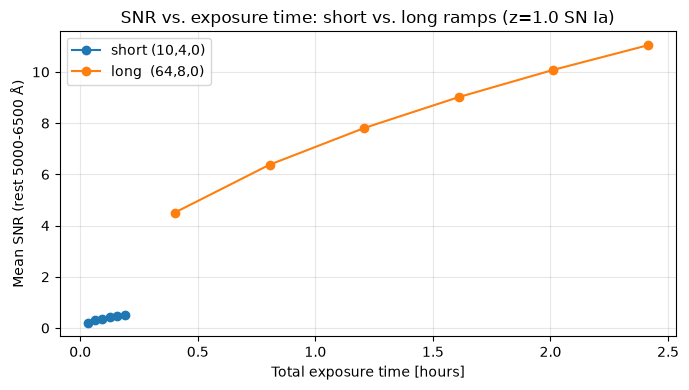

In [6]:
# reload the target with its default configuration, and vary the number of ramps
snia = slicersim.LazuliSupernova(redshift=1.0)

nmd_options = {
    "short (10,4,0)": (10, 4, 0),
    "long  (64,8,0)": (64, 8, 0),
}

fig, ax = plt.subplots(figsize=(7, 4))

for label, nmd in nmd_options.items():
    exptimes, snrs = [], []
    for nr in range(1, 7):
        snia.change_detector(nmd=nmd, nramps=nr)
        lbda, flux, var = snia.get_spectrum(incl_error=False)
        # mean SNR per wavelength bin over rest-frame 5000-6500 Å
        z = snia.get_properties("redshift")
        mask = (lbda > 5000 * (1 + z)) & (lbda < 6500 * (1 + z))
        snr_mean = np.mean(flux[mask] / np.sqrt(var[mask]))
        exptimes.append(snia.get_exposure_time() / 3600)
        snrs.append(snr_mean)
    ax.plot(exptimes, snrs, "o-", label=label)

ax.set_xlabel("Total exposure time [hours]")
ax.set_ylabel("Mean SNR (rest 5000-6500 Å)")
ax.set_title("SNR vs. exposure time: short vs. long ramps (z=1.0 SN Ia)")
ax.legend()
ax.grid(alpha=0.3)
plt.tight_layout()

Long ramps are much more efficient: for a given exposure time, the readout noise is paid
once per ramp, so fewer, longer ramps give a much higher SNR.

***
## 5. Using `setup_to_snr` to let slicersim choose the mode

Rather than hand-tuning the MACC parameters, `setup_to_snr()` searches the allowed readout
modes (number of groups, up to `max_group`, and number of ramps) for one that reaches your
requested SNR.

In [7]:
snia = slicersim.LazuliSupernova(redshift=1.0)
_ = snia.setup_to_snr(15, per_resolution=True, lbda_range=[5000, 7000], frame="rest")

cfg = snia.get_readout_config()
print(f"Chosen readout: nmd={cfg['nmd']},  nramps={cfg['nramps']}")
print(f"Total exposure: {snia.get_exposure_time()/3600:.2f} hours")

Chosen readout: nmd=(64, 8, 0),  nramps=6
Total exposure: 2.41 hours


***
## Summary

| Parameter | Effect |
|-----------|--------|
| More `ngroups` | Longer ramp → more photons per ramp and lower effective RON |
| More `nframes_per_group` | Averaging frames reduces the RON of each group |
| More `nramps` | Increases the total exposure time linearly; the RON is paid on each ramp |
| `setup_to_snr()` | Automatically picks a MACC mode that reaches the requested SNR |